## COMPAS - 3 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals and Regularization coefficient

In [91]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [92]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

In [93]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes, plot_pareto_plotly
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import LogRegScalarization

### Dataset and Model

In [94]:
# Setting a seed for reproducibility
seed = 42

In [95]:
data = pd.read_csv("dataset/compas_onerace.csv")
data = data.drop("Unnamed: 0", axis=1)

fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)

In [96]:
#tol = 10**-3
#max_iter = 100

tol = 10**-30
max_iter = 100

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [97]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 25,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 3
results = {}

In [98]:
# Logistic Regression with equal weight to use as baseline model
equal = LogRegScalarization(num_objs=3,
                            X=X_train, 
                            y=y_train, 
                            fair_feat=fair_feature,
                            #tol=tol, max_iter=max_iter
                            )
equal.optimize(np.array([1/3, 1/3, 1/3]))

## MOLA

02:20:51 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 25, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
02:20:51 | DEBUG | machinemoo | Finding 1th individual minimum
02:20:51 | DEBUG | machinemoo | Finding 2th individual minimum
02:20:51 | DEBUG | machinemoo | Finding 3th individual minimum
02:20:51 | DEBUG | machinemoo | Calculated weights: [0.         0.93679867 0.06320133]
02:20:51 | DEBUG | machinemoo | Importance: 0.08172162460114907
02:20:51 | DEBUG | machinemoo | Importance: 0.08172162460114907
02:20:51 | DEBUG | machinemoo | y_sup: [6.06319667e-01 6.97663082e-01 1.00000000e-08]
02:20:51 | DEBUG | machinemoo | y_und: [6.06319667e-01 6.10428090e-01 1.00000000e-08]
02:20:51 | DEBUG | machinemoo | Global lower bound (y*): [6.06319657e-01 6.10428080e-01 1.55216615e-20]
02:20:51 | DEBUG | machinemoo | Iteration 1
02:20:51 | DEBUG | machinemoo | Solutions list: [array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.6165940

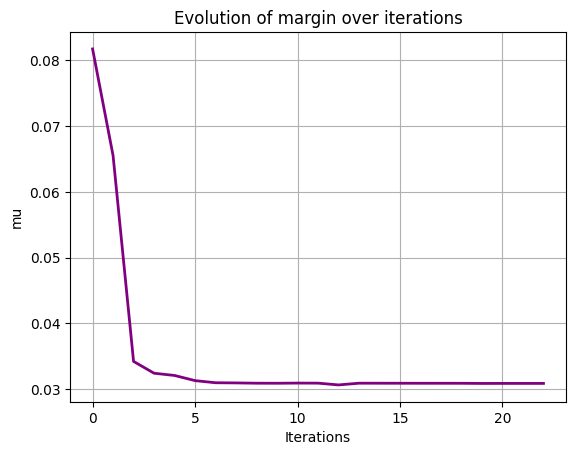

02:20:53 | INFO | machinemoo | Fit runtime: 2.15 seconds


In [99]:
method = 'mola'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               lower_bound_estimate=0.01
                               )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [109]:
sol = np.array([0.62886868, 0.63784723, 0.08136123])
w = np.array([0.85729344, 0.,         0.14270656])
sup = np.array([6.42412216e-01, 6.45603598e-01, 1.00000000e-08])
und = np.array([6.06319667e-01, 6.45603598e-01, 1.00000000e-08])
w@sol, w@sup, w@und

(np.float64(0.5507357752361279),
 np.float64(0.5507357799797286),
 np.float64(0.51979387448915))

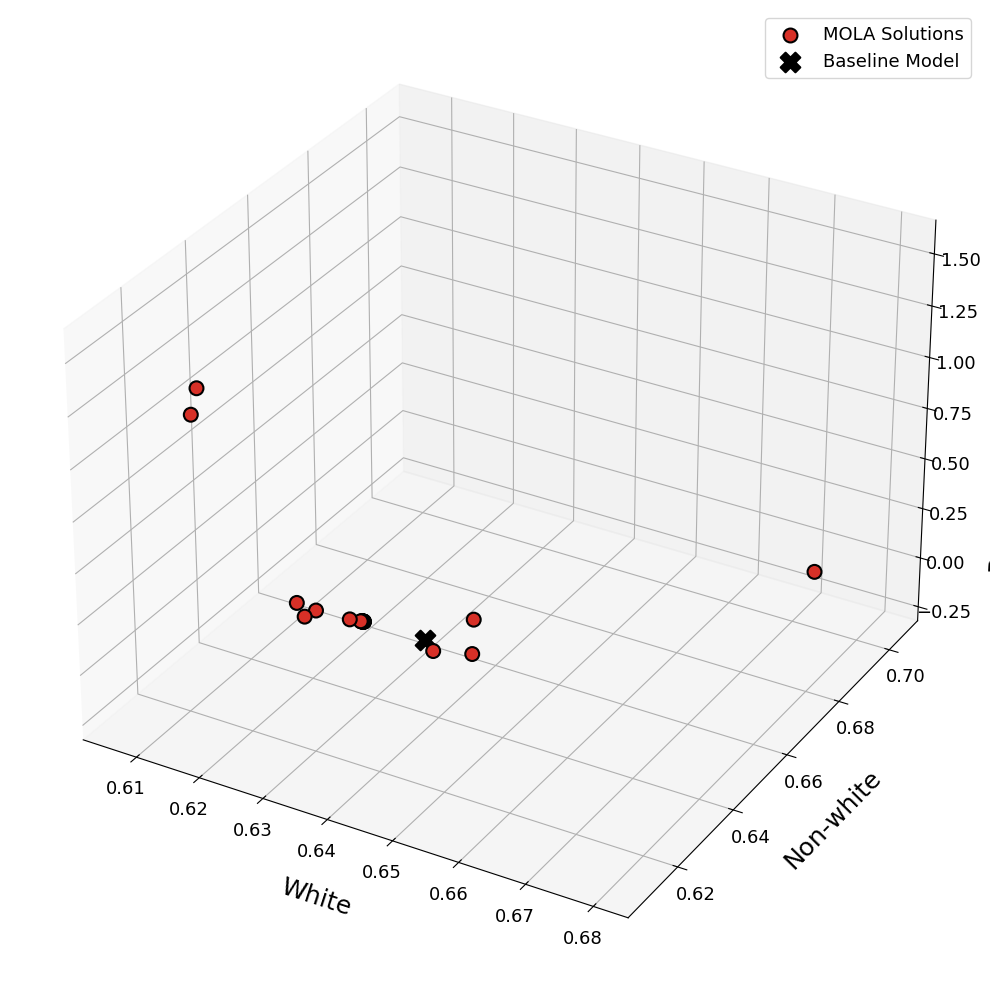

In [100]:
title = title="Loss Trade-offs for White and Non-White Person and L2 Coefficient"
plot_pareto(methods={'mola': objs},
            labels=("White", "Non-White", "Regularization Coefficient"), 
            title=title,
            point = equal.objs,
            save_path='images/3_objs_mola.pdf',
            figsize=(10,10),
            fontsize=18,
            s_factor=2
            )

02:20:53 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 25, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
02:20:53 | DEBUG | machinemoo | Finding 1th individual minimum
02:20:53 | DEBUG | machinemoo | Finding 2th individual minimum
02:20:53 | DEBUG | machinemoo | Finding 3th individual minimum


L [ 4.40465005 10.42433571  2.        ]
Objs delta: [ 1.57858957e-17  7.14853218e-11 -1.61050686e-09]
Grad squar: [1.39062693e-16 4.52356291e-03 4.68883492e+00]
L [ 4.40465005 10.42433571  2.        ]
Objs delta: [2.16696831e-11 7.23847965e-18 6.67408643e-11]
Grad squar: [7.81048597e-04 1.50912684e-16 5.35368866e+00]
L [ 4.40465005 10.42433571  2.        ]
Objs delta: [-3.75557100e-11 -1.19228697e-10  1.56784459e-20]
Grad squar: [9.55838998e-02 9.12313502e-01 6.27137837e-20]


02:20:53 | DEBUG | machinemoo | Calculated weights: [0.         0.93679867 0.06320133]
02:20:53 | DEBUG | machinemoo | Importance: 0.07594538003780937
02:20:53 | DEBUG | machinemoo | Importance: 0.07594538003780937
02:20:53 | DEBUG | machinemoo | y_sup: [6.12444108e-01 6.97663082e-01 1.00000000e-08]
02:20:53 | DEBUG | machinemoo | y_und: [6.12444108e-01 6.16594030e-01 1.00000000e-08]
02:20:53 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.        ]
02:20:53 | DEBUG | machinemoo | Iteration 1
02:20:53 | DEBUG | machinemoo | Solutions list: [array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([6.74077675e-01, 6.97663082e-01, 1.56784459e-20])]
02:20:53 | DEBUG | machinemoo | New solution added [0.62538289 0.62673147 0.21385937]


L [ 4.40465005 10.42433571  2.        ]
Objs delta: [-5.91275800e-05 -1.37686485e-04  2.72404297e-03]
Grad squar: [0.0072321  0.0009734  0.85543749]


02:20:53 | DEBUG | machinemoo | Calculated weights: [0.         0.75093449 0.24906551]
02:20:53 | DEBUG | machinemoo | Importance: 0.06087754483730484
02:20:53 | DEBUG | machinemoo | Importance: 0.06087754483730484
02:20:53 | DEBUG | machinemoo | y_sup: [0.62544203 0.61659403 0.24442384]
02:20:53 | DEBUG | machinemoo | y_und: [6.25442027e-01 6.16594030e-01 1.00000000e-08]
02:20:53 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.        ]
02:20:53 | DEBUG | machinemoo | Iteration 2
02:20:53 | DEBUG | machinemoo | Solutions list: [array([0.62538289, 0.62673147, 0.21385937]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([6.74077675e-01, 6.97663082e-01, 1.56784459e-20])]
02:20:53 | DEBUG | machinemoo | New solution added [0.63999702 0.6383386  0.03475655]


...

02:20:55 | DEBUG | machinemoo | Calculated weights: [0.84517258 0.         0.15482742]
02:20:55 | DEBUG | machinemoo | Importance: 0.025524963548598567
02:20:55 | DEBUG | machinemoo | Importance: 0.025524963548598567
02:20:55 | DEBUG | machinemoo | y_sup: [0.642645  0.6598216 0.       ]
02:20:55 | DEBUG | machinemoo | y_und: [0.61244411 0.6598216  0.        ]
02:20:55 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.        ]
02:20:55 | DEBUG | machinemoo | Iteration 21
02:20:55 | DEBUG | machinemoo | Solutions list: [array([0.62991273, 0.63902048, 0.06950296]), array([0.62936105, 0.63839972, 0.07557015]), array([0.62936105, 0.63839972, 0.07557015]), array([0.62936105, 0.63839972, 0.07557015]), array([0.62936105, 0.63839972, 0.07557015]), array([0.62944875, 0.63849828, 0.07457643]), array([0.62943568, 0.63848359, 0.07472378]), array([0.62940693, 0.63845128, 0.07504886]), array([0.62932575, 0.63836008, 0.07597324]), array([0.6293436 , 0.63838013, 0.07576917]), ar

L [ 4.40465005 10.42433571  2.        ]
Objs delta: [-0.00073898 -0.00170748  0.00541391]
Grad squar: [0.00241221 0.03220374 0.28752106]


02:20:55 | DEBUG | machinemoo | Calculated weights: [0.84517258 0.         0.15482742]
02:20:55 | DEBUG | machinemoo | Importance: 0.025524963548598567
02:20:55 | DEBUG | machinemoo | Importance: 0.025524963548598567
02:20:55 | DEBUG | machinemoo | y_sup: [0.642645  0.6598216 0.       ]
02:20:55 | DEBUG | machinemoo | y_und: [0.61244411 0.6598216  0.        ]
02:20:55 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.        ]
02:20:55 | DEBUG | machinemoo | Iteration 22
02:20:55 | DEBUG | machinemoo | Solutions list: [array([0.62969183, 0.63877168, 0.07188026]), array([0.62991273, 0.63902048, 0.06950296]), array([0.62936105, 0.63839972, 0.07557015]), array([0.62936105, 0.63839972, 0.07557015]), array([0.62936105, 0.63839972, 0.07557015]), array([0.62936105, 0.63839972, 0.07557015]), array([0.62944875, 0.63849828, 0.07457643]), array([0.62943568, 0.63848359, 0.07472378]), array([0.62940693, 0.63845128, 0.07504886]), array([0.62932575, 0.63836008, 0.07597324]), ar

L [ 4.40465005 10.42433571  2.        ]
Objs delta: [-0.00073898 -0.00170748  0.00541391]
Grad squar: [0.00241221 0.03220374 0.28752106]


02:20:55 | DEBUG | machinemoo | Calculated weights: [0.83414242 0.01163498 0.1542226 ]
02:20:55 | DEBUG | machinemoo | Importance: 0.02504822281805951
02:20:55 | DEBUG | machinemoo | Importance: 0.025048222818059518
02:20:55 | DEBUG | machinemoo | y_sup: [6.42472821e-01 6.59821599e-01 1.00000000e-08]
02:20:55 | DEBUG | machinemoo | y_und: [6.12444108e-01 6.59821599e-01 1.00000000e-08]
02:20:55 | DEBUG | machinemoo | Global lower bound (y*): [0.6124441  0.61659402 0.        ]


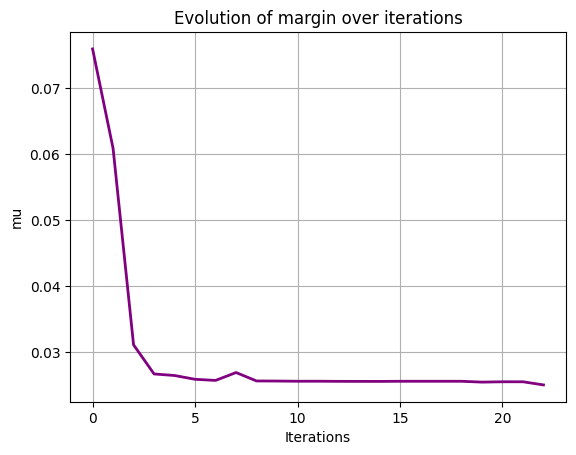

02:20:55 | INFO | machinemoo | Fit runtime: 2.07 seconds


In [101]:
# Test with gradient
method = 'mola'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               lower_bound_estimate="lipshitz"  # Options: "zero", "lipshitz", or a float value
                               )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

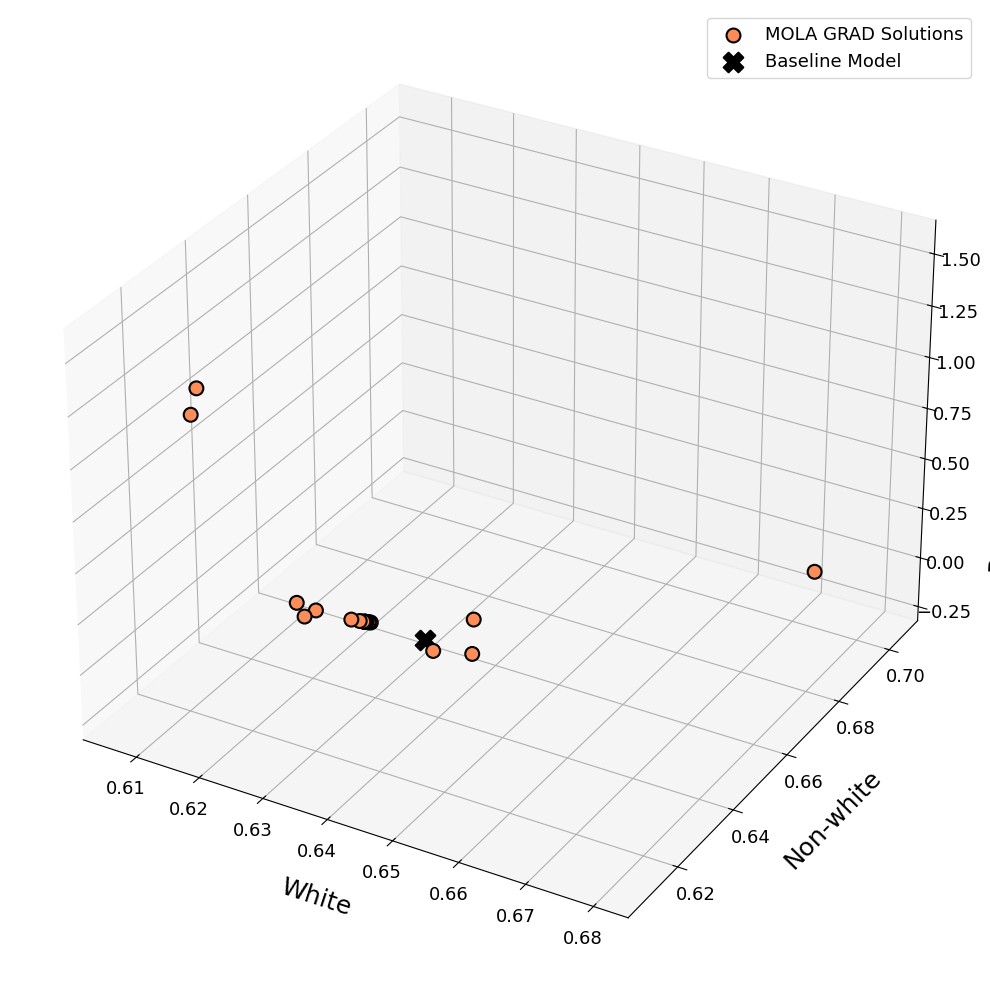

In [102]:
title = title="Loss Trade-offs for White and Non-White Person and L2 Coefficient"
plot_pareto(methods={'mola_grad': results['mola_grad']['objectives']},
            color=['#fc8d59'],
            labels=("White", "Non-White", "Regularization Coefficient"), 
            title=title,
            point = equal.objs,
            save_path='images/3_objs_mola_grad.pdf',
            figsize=(10,10),
            fontsize=18,
            s_factor=2
            )

### MONISE

In [103]:
method = 'monise'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               lower_bound_estimate=0.01
                               )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

02:20:56 | DEBUG | machinemoo | Filtered parameters for monise: {'nodeTimeLimit': 2, 'targetSize': 25, 'targetGap': 0, 'nodeGap': 0.05, 'norm': False}
02:20:56 | DEBUG | machinemoo | Finding 1th individual minima
02:20:56 | DEBUG | machinemoo | Finding 2th individual minima
02:20:56 | DEBUG | machinemoo | Finding 3th individual minima
02:20:56 | DEBUG | machinemoo | 4th solution - importance: 1.0
02:20:56 | DEBUG | machinemoo | 5th solution - importance: 1.0
02:20:56 | DEBUG | machinemoo | 6th solution - importance: 1.0
02:20:56 | DEBUG | machinemoo | 7th solution - importance: 1.0
02:20:56 | DEBUG | machinemoo | 8th solution - importance: 1.0
02:20:56 | DEBUG | machinemoo | 9th solution - importance: 0.6610363575004276
02:20:56 | DEBUG | machinemoo | 10th solution - importance: 0.3682794297868727


Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic lic

02:20:56 | DEBUG | machinemoo | 11th solution - importance: 0.1999845632389618
02:20:56 | DEBUG | machinemoo | 12th solution - importance: 0.14062056521902852
02:20:56 | DEBUG | machinemoo | 13th solution - importance: 0.11459593190092246
02:20:56 | DEBUG | machinemoo | 14th solution - importance: 0.08855594998059131


Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11


02:20:56 | DEBUG | machinemoo | 15th solution - importance: 0.056229031790262375
02:20:56 | DEBUG | machinemoo | 16th solution - importance: 0.05259203731497238
02:20:56 | DEBUG | machinemoo | 17th solution - importance: 0.04332571474438742


...

Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11


02:20:57 | DEBUG | machinemoo | 22th solution - importance: 0.02578547561167061
02:20:57 | DEBUG | machinemoo | 23th solution - importance: 0.025119186709494604


Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11


02:20:57 | DEBUG | machinemoo | 24th solution - importance: 0.02066374151845089
02:20:57 | DEBUG | machinemoo | 25th solution - importance: 0.018376940799902312


Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11
Set parameter Username
Set parameter LicenseID to value 2687630
Academic license - for non-commercial use only - expires 2026-07-11


### Ramdon Weighted Sum

In [104]:
method = 'random_weight'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               lower_bound_estimate=0.01
                               )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

02:20:57 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
02:20:57 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 25, 'norm': False}
02:20:57 | DEBUG | machinemoo | Finding 1th individual minima
02:20:57 | DEBUG | machinemoo | Finding 2th individual minima
02:20:57 | DEBUG | machinemoo | Finding 3th individual minima
02:20:57 | DEBUG | machinemoo | 4th solution
02:20:57 | DEBUG | machinemoo | 5th solution
02:20:57 | DEBUG | machinemoo | 6th solution
02:20:57 | DEBUG | machinemoo | 7th solution
02:20:57 | DEBUG | machinemoo | 8th solution
02:20:57 | DEBUG | machinemoo | 9th solution
02:20:57 | DEBUG | machinemoo | 10th solution
02:20:57 | DEBUG | machinemoo | 11th solution
02:20:57 | DEBUG | machinemoo | 12th solution
02:20:57 | DEBUG | machinemoo | 13th solution
02:20:57 | DEBUG | machinemoo | 14th solution
02:20:57 | DEBUG | machinemoo | 15th solution
02:20:57 | DEBUG | machinemoo | 16th solution
0

In [105]:
import numpy as np
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Supondo que `solutions` seja seu array (N x M)
solutions = results['random_weight']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]


print(f"mola: {len(results['mola']['objectives'])}")
print(f"mola_grad: {len(results['mola_grad']['objectives'])}")

print(f"Número de soluções não-dominadas (RW): {len(non_dominated_solutions)}")
print(non_dominated_solutions)

mola: 25
mola_grad: 25
Número de soluções não-dominadas (RW): 25
[[6.12444098e-01 6.18579757e-01 1.17220873e+00]
 [6.14505454e-01 6.16594020e-01 1.33842217e+00]
 [6.74077675e-01 6.97663082e-01 1.56784459e-20]
 [6.40808353e-01 6.48791713e-01 1.34401395e-02]
 [6.42713486e-01 6.42041959e-01 1.92416152e-02]
 [6.13855662e-01 6.20456172e-01 7.00371003e-01]
 [6.35583333e-01 6.42238439e-01 2.97690571e-02]
 [6.32729823e-01 6.36170552e-01 5.65619953e-02]
 [6.38776360e-01 6.40069759e-01 2.74868335e-02]
 [6.24593050e-01 6.31594452e-01 1.51023918e-01]
 [6.19894901e-01 6.25674901e-01 2.87886875e-01]
 [6.37852878e-01 6.43806314e-01 2.17460593e-02]
 [6.22133644e-01 6.29178078e-01 2.09660742e-01]
 [6.63402779e-01 6.82344741e-01 5.31956290e-04]
 [6.32484282e-01 6.36501013e-01 5.58071350e-02]
 [6.14640118e-01 6.18236353e-01 7.60145915e-01]
 [6.38407474e-01 6.43936094e-01 2.04936992e-02]
 [6.16613382e-01 6.22725825e-01 4.46341107e-01]
 [6.30658685e-01 6.35380227e-01 6.97843623e-02]
 [6.42143785e-01 6.4890

In [106]:
# Supondo que `solutions` seja seu array (N x M)
solutions = results['monise']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]

print(f"Número de soluções não-dominadas: {len(non_dominated_solutions)}")
print(non_dominated_solutions)

Número de soluções não-dominadas: 25
[[6.12444098e-01 6.18579757e-01 1.17220873e+00]
 [6.14505454e-01 6.16594020e-01 1.33842217e+00]
 [6.74077675e-01 6.97663082e-01 1.56784459e-20]
 [6.25382890e-01 6.26731471e-01 2.13859371e-01]
 [6.31316520e-01 6.40611594e-01 5.59212494e-02]
 [6.47072172e-01 6.43706235e-01 1.49056719e-02]
 [6.17656886e-01 6.25221979e-01 3.81144071e-01]
 [6.43908479e-01 6.58804762e-01 8.16057707e-03]
 [6.14781002e-01 6.17492098e-01 8.86621922e-01]
 [6.58754329e-01 6.54959864e-01 4.88096670e-03]
 [6.12860798e-01 6.19338311e-01 8.98880762e-01]
 [6.33362921e-01 6.39280115e-01 4.33488264e-02]
 [6.48926569e-01 6.65377335e-01 4.24981435e-03]
 [6.15554014e-01 6.18296907e-01 7.43695524e-01]
 [6.33594972e-01 6.33350398e-01 8.05497049e-02]
 [6.42416484e-01 6.45194688e-01 1.43605136e-02]
 [6.53429151e-01 6.77948549e-01 2.14231875e-03]
 [6.20604613e-01 6.25831648e-01 2.68250564e-01]
 [6.65739341e-01 6.63107848e-01 2.40118201e-03]
 [6.14244725e-01 6.18696552e-01 7.26327835e-01]
 [6

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

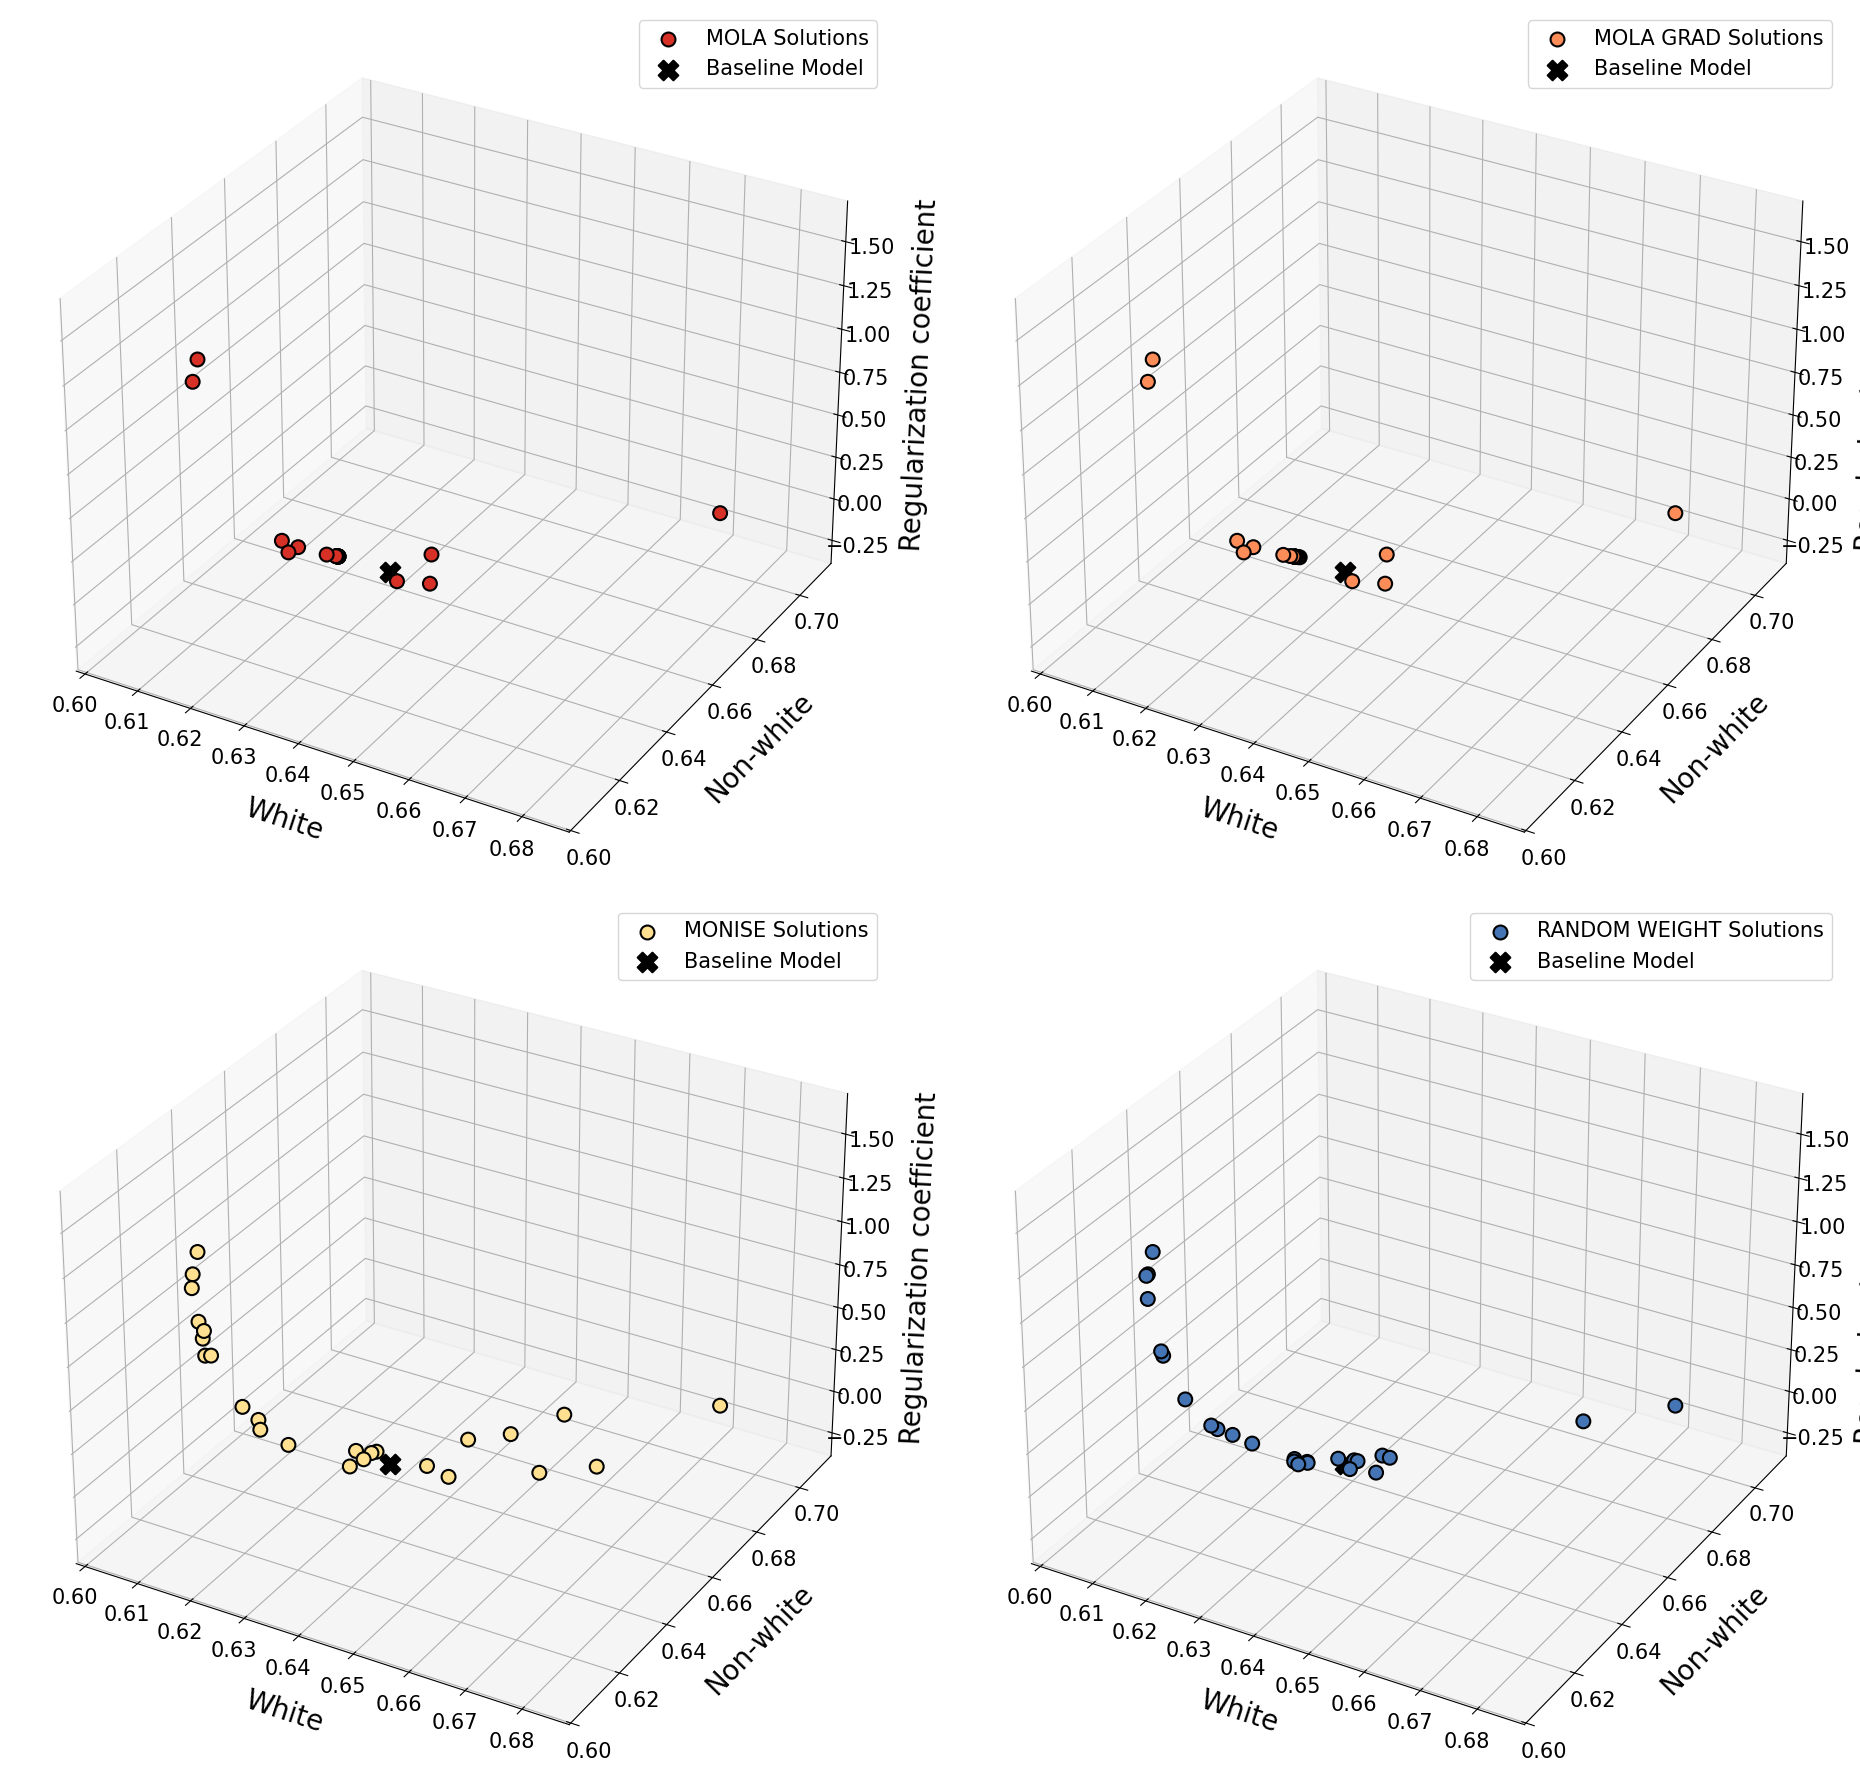

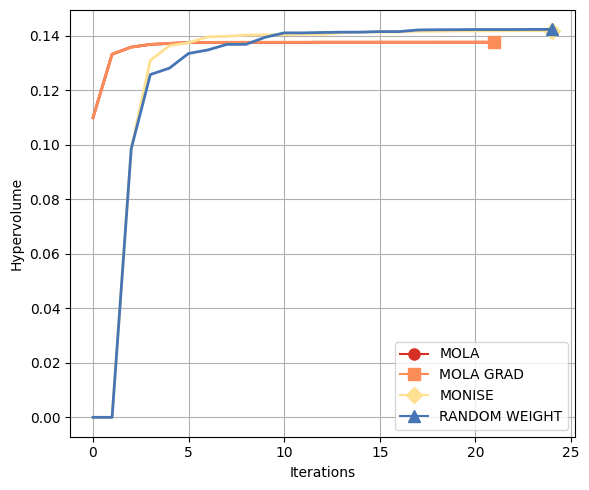

<Figure size 640x480 with 0 Axes>

In [107]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

axes_label = ["White", "Non-White", "Regularization Coefficient"]
color = ['#d73027', '#fc8d59', '#fee090', '#4575b4']
plot_pareto(methods=pareto_dict,
               labels=axes_label, 
               title=title,
               point = equal.objs,
               save_path='images/3_objs_methods.pdf',
               figsize=(10,9),
               fontsize=20,
               s_factor=2,
               color=color
               )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path="images/3_objs_hypervolume.pdf", colors=color)

In [108]:
#Monise achou melhor solução na iteração 36
#Grad achou melhor solução na iteração 15